# Baby Cry Classification — Notebook 2
## Entraînement · Comparaison · Interprétation

> **Pré-requis** : Notebook 1 exécuté (`X_train`, `y_train`, `X_val`, `y_val`, `X_test`, `y_test`, `train_loader`, `val_loader`, `test_loader`, `class_names` disponibles)  
> **models.py** placé dans le même dossier que ce notebook.

---
**Plan :**
1. Imports & configuration GPU  
2. Chargement des modèles  
3. Boucle d'entraînement universelle  
4. Entraînement des 3 architectures  
5. Courbes d'apprentissage  
6. Tableau comparatif  
7. Matrice de confusion  
8. Courbe ROC multiclasse  
9. Grad-CAM (visualisation des régions actives)  
10. SHAP (importance des features)  
11. Conclusion & discussion

In [8]:
# ====================== CHARGEMENT DES DONNÉES ======================
import pickle
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split

print("Chargement des données prétraitées...")

with open('./saved_data/preprocessed_data.pkl', 'rb') as f:
    data = pickle.load(f)

X_train = data['X_train']
y_train = data['y_train']
X_val   = data['X_val']
y_val   = data['y_val']
X_test  = data['X_test']
y_test  = data['y_test']
class_names = data['class_names']

print(f"✅ Données chargées ! Classes : {class_names}")

# ====================== RECRÉATION DES DATASETS & DATALOADERS ======================
class BabyCryDataset(torch.utils.data.Dataset):
    def __init__(self, specs, labels):
        self.specs = torch.FloatTensor(specs).unsqueeze(1)   # (N, 1, H, W)
        self.labels = torch.LongTensor(labels)
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return self.specs[idx], self.labels[idx]

# Création des datasets
train_ds = BabyCryDataset(X_train, y_train)
val_ds   = BabyCryDataset(X_val, y_val)
test_ds  = BabyCryDataset(X_test, y_test)

# DataLoaders
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False, num_workers=0)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

Chargement des données prétraitées...
✅ Données chargées ! Classes : ['belly_pain', 'burping', 'discomfort', 'hungry', 'tired']
Train: 1337 | Val: 286 | Test: 287


## 1. Imports & Configuration GPU

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os, time, copy
from tqdm.notebook import tqdm

from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, auc, accuracy_score, f1_score
)
from sklearn.preprocessing import label_binarize

# === Import des modèles ===
from notebooks.models import (
    SimpleCNN, 
    BabyCryResNet, 
    get_resnet18_transfer, 
    count_params
)

# --- Device ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Device utilisé : {device}")
if torch.cuda.is_available():
    print(f"   GPU : {torch.cuda.get_device_name(0)}")

# --- Reproductibilité ---
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# --- Hyperparamètres ---
NUM_CLASSES = 5
NUM_EPOCHS = 60
PATIENCE = 15
LR = 1e-3
WEIGHT_DECAY = 1e-4

print(f"Nombre de classes : {NUM_CLASSES}")

✅ Device utilisé : cpu
Nombre de classes : 5


## 2. Chargement des 3 Modèles

In [10]:
print("=== Chargement des 3 architectures ===\n")

simple_cnn = SimpleCNN(num_classes=NUM_CLASSES).to(device)
baby_resnet = BabyCryResNet(num_classes=NUM_CLASSES).to(device)
resnet18_transfer = get_resnet18_transfer(num_classes=NUM_CLASSES, freeze_backbone=True).to(device)

print("="*60)
print("SimpleCNN")
print("="*60)
count_params(simple_cnn)

print("\n" + "="*60)
print("BabyCryResNet (Custom)")
print("="*60)
count_params(baby_resnet)

print("\n" + "="*60)
print("ResNet18 - Transfer Learning")
print("="*60)
count_params(resnet18_transfer)

=== Chargement des 3 architectures ===

SimpleCNN
Total parameters     : 2,489,029
Trainable parameters : 2,489,029 (100.00%)

BabyCryResNet (Custom)
Total parameters     : 11,172,805
Trainable parameters : 11,172,805 (100.00%)

ResNet18 - Transfer Learning
Total parameters     : 11,172,805
Trainable parameters : 4,724,229 (42.28%)


(11172805, 4724229)

## 3. Boucle d'Entraînement Universelle

La fonction `train_one_model` gère :
- **Early stopping** (arrêt si val_loss ne s'améliore pas pendant `patience` epochs)
- **Learning rate scheduler** (ReduceLROnPlateau)
- **Sauvegarde du meilleur modèle** (best weights selon val_loss)
- **Historique complet** (loss + accuracy train/val par epoch)

In [13]:
def train_one_model(model, train_loader, val_loader, model_name="Model",
                    num_epochs=NUM_EPOCHS, lr=LR, patience=PATIENCE):
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=WEIGHT_DECAY
    )
    
    # Correction : plus de 'verbose'
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, 
        mode='min', 
        factor=0.5, 
        patience=7,
        # verbose=True  ← supprimé
    )

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'lr': []}
    best_val_loss = float('inf')
    best_weights = copy.deepcopy(model.state_dict())
    patience_counter = 0

    print(f"\n Entraînement de {model_name}...")

    for epoch in range(1, num_epochs + 1):
        # === TRAIN ===
        model.train()
        train_loss = train_correct = train_total = 0.0
        
        for specs, labels in train_loader:
            specs, labels = specs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(specs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * specs.size(0)
            train_correct += (outputs.argmax(dim=1) == labels).sum().item()
            train_total += specs.size(0)

        # === VALIDATION ===
        model.eval()
        val_loss = val_correct = val_total = 0.0
        
        with torch.no_grad():
            for specs, labels in val_loader:
                specs, labels = specs.to(device), labels.to(device)
                outputs = model(specs)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item() * specs.size(0)
                val_correct += (outputs.argmax(dim=1) == labels).sum().item()
                val_total += specs.size(0)

        # Calcul des métriques
        train_loss /= train_total
        val_loss   /= val_total
        train_acc   = train_correct / train_total
        val_acc     = val_correct / val_total
        current_lr  = optimizer.param_groups[0]['lr']

        # Sauvegarde historique
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['lr'].append(current_lr)

        scheduler.step(val_loss)

        # Early Stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_weights = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"⏹ Early stopping activé à l'epoch {epoch}")
                break

        # Affichage
        if epoch % 5 == 0 or epoch == 1:
            print(f"Epoch {epoch:03d} | "
                  f"Train Loss: {train_loss:.4f} Acc: {train_acc:.3f} | "
                  f"Val Loss: {val_loss:.4f} Acc: {val_acc:.3f} | "
                  f"LR: {current_lr:.2e}")

    # Charger les meilleurs poids
    model.load_state_dict(best_weights)
    print(f"✅ {model_name} terminé ! Meilleure val_loss = {best_val_loss:.4f}\n")
    
    return history

## 4. Entraînement des 3 Architectures

Le ResNet-18 Transfer utilise une stratégie 2 phases :
- **Phase 1** (epochs 1–20) : layer1 & layer2 gelés, lr = 1e-3
- **Phase 2** (epochs 21+) : tout dégelé, lr = 1e-5

In [14]:
# Entraînement SimpleCNN
history_cnn = train_one_model(simple_cnn, train_loader, val_loader, "SimpleCNN")

# Entraînement BabyCryResNet
history_resnet = train_one_model(baby_resnet, train_loader, val_loader, "BabyCryResNet")

# Entraînement ResNet18 Transfer (2 phases)
print("\n--- Phase 1 : Transfer Learning (backbone gelé) ---")
history_p1 = train_one_model(resnet18_transfer, train_loader, val_loader, 
                            "ResNet18-Transfer (Phase 1)", num_epochs=20, lr=1e-3, patience=10)

print("\n--- Phase 2 : Fine-tuning complet ---")
for param in resnet18_transfer.parameters():
    param.requires_grad = True

history_p2 = train_one_model(resnet18_transfer, train_loader, val_loader, 
                            "ResNet18-Transfer (Phase 2)", num_epochs=40, lr=1e-5, patience=15)

history_transfer = {k: history_p1[k] + history_p2[k] for k in history_p1}


 Entraînement de SimpleCNN...
Epoch 001 | Train Loss: 1.9604 Acc: 0.251 | Val Loss: 1.4864 Acc: 0.346 | LR: 1.00e-03
Epoch 005 | Train Loss: 1.2516 Acc: 0.440 | Val Loss: 1.2815 Acc: 0.434 | LR: 1.00e-03
Epoch 010 | Train Loss: 0.9688 Acc: 0.586 | Val Loss: 0.8520 Acc: 0.661 | LR: 1.00e-03
Epoch 015 | Train Loss: 0.7213 Acc: 0.702 | Val Loss: 0.8876 Acc: 0.654 | LR: 1.00e-03
Epoch 020 | Train Loss: 0.5833 Acc: 0.773 | Val Loss: 0.5685 Acc: 0.776 | LR: 1.00e-03
Epoch 025 | Train Loss: 0.4091 Acc: 0.832 | Val Loss: 0.5791 Acc: 0.783 | LR: 1.00e-03
Epoch 030 | Train Loss: 0.2972 Acc: 0.886 | Val Loss: 0.5603 Acc: 0.808 | LR: 1.00e-03
Epoch 035 | Train Loss: 0.2662 Acc: 0.884 | Val Loss: 0.6438 Acc: 0.762 | LR: 1.00e-03
Epoch 040 | Train Loss: 0.2384 Acc: 0.913 | Val Loss: 0.4750 Acc: 0.839 | LR: 1.00e-03
Epoch 045 | Train Loss: 0.0970 Acc: 0.974 | Val Loss: 0.2673 Acc: 0.930 | LR: 5.00e-04
Epoch 050 | Train Loss: 0.0782 Acc: 0.977 | Val Loss: 0.3143 Acc: 0.923 | LR: 5.00e-04
Epoch 055 | 

## 5. Courbes d'Apprentissage

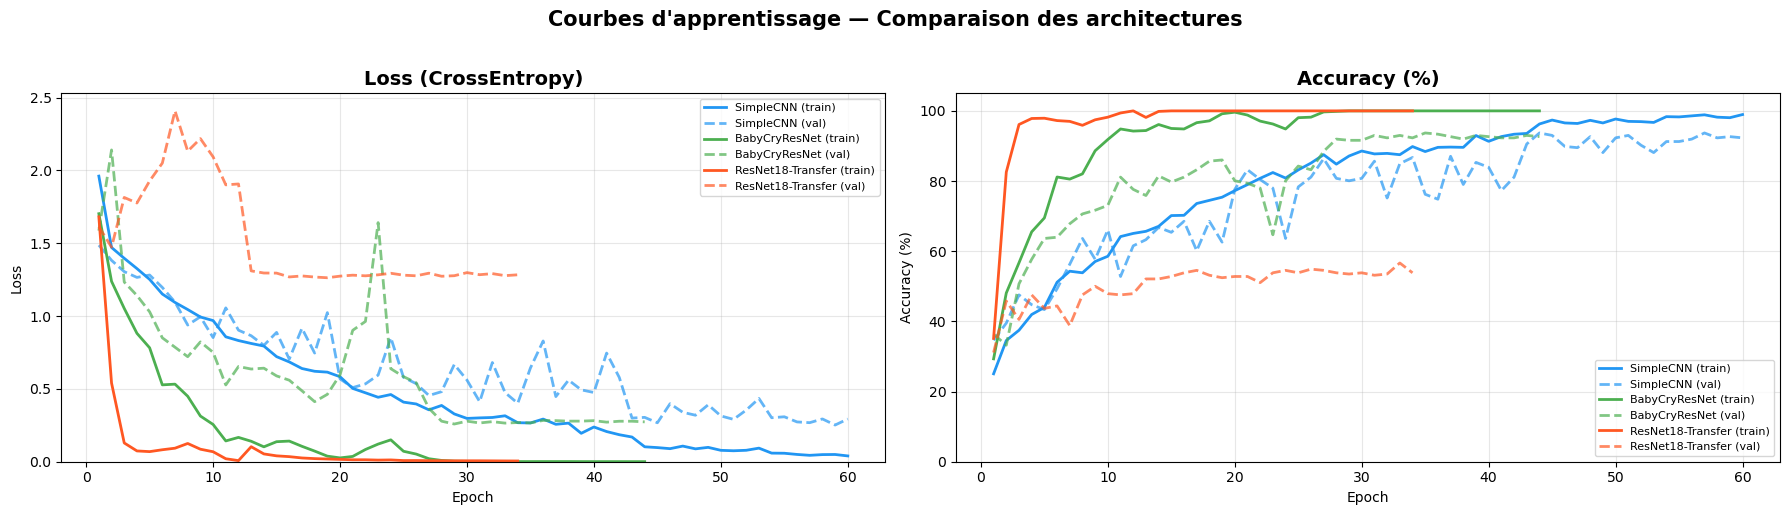

💾 Sauvegardé : learning_curves.png


In [15]:
def plot_learning_curves(histories, names, figsize=(18, 5)):
    """
    Affiche loss et accuracy train/val pour chaque modèle.
    histories : liste de dicts retournés par train_one_model
    names     : liste de noms de modèles correspondants
    """
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    colors = ['#2196F3', '#4CAF50', '#FF5722']
    styles_val = ['--', '--', '--']

    for i, (hist, name, color) in enumerate(zip(histories, names, colors)):
        epochs = range(1, len(hist['train_loss']) + 1)

        # Loss
        axes[0].plot(epochs, hist['train_loss'],
                     color=color, linewidth=2, label=f"{name} (train)")
        axes[0].plot(epochs, hist['val_loss'],
                     color=color, linewidth=2, linestyle='--',
                     label=f"{name} (val)", alpha=0.7)

        # Accuracy
        axes[1].plot(epochs, [a*100 for a in hist['train_acc']],
                     color=color, linewidth=2, label=f"{name} (train)")
        axes[1].plot(epochs, [a*100 for a in hist['val_acc']],
                     color=color, linewidth=2, linestyle='--',
                     label=f"{name} (val)", alpha=0.7)

    for ax, title, ylabel in zip(
        axes,
        ['Loss (CrossEntropy)', 'Accuracy (%)'],
        ['Loss', 'Accuracy (%)']
    ):
        ax.set_title(title, fontsize=14, fontweight='bold')
        ax.set_xlabel('Epoch')
        ax.set_ylabel(ylabel)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    axes[0].set_ylim(bottom=0)
    axes[1].set_ylim(0, 105)

    plt.suptitle("Courbes d'apprentissage — Comparaison des architectures",
                 fontsize=15, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig("learning_curves.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("💾 Sauvegardé : learning_curves.png")

# Tracer les courbes
plot_learning_curves(
    histories=[history_cnn, history_resnet, history_transfer],
    names=["SimpleCNN", "BabyCryResNet", "ResNet18-Transfer"]
)

## 6. Évaluation sur le Test Set & Tableau Comparatif

In [16]:
def evaluate_model(model, loader, model_name):
    """
    Évalue un modèle sur un DataLoader.
    Retourne : dict avec accuracy, f1, y_true, y_pred, y_proba
    """
    model.eval()
    all_preds, all_labels, all_proba = [], [], []

    with torch.no_grad():
        for specs, labels in loader:
            specs = specs.to(device)
            outputs = model(specs)
            proba = torch.softmax(outputs, dim=1)
            preds = outputs.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_proba.extend(proba.cpu().numpy())

    y_true  = np.array(all_labels)
    y_pred  = np.array(all_preds)
    y_proba = np.array(all_proba)

    acc = accuracy_score(y_true, y_pred) * 100
    f1  = f1_score(y_true, y_pred, average='macro') * 100

    print(f"\n{'='*50}")
    print(f"  {model_name}")
    print(f"  Accuracy : {acc:.2f}%  |  F1-macro : {f1:.2f}%")
    print(f"{'='*50}")
    print(classification_report(y_true, y_pred,
                                 target_names=class_names, digits=3))

    return {
        'name': model_name,
        'accuracy': acc,
        'f1_macro': f1,
        'y_true':  y_true,
        'y_pred':  y_pred,
        'y_proba': y_proba
    }

# Évaluer les 3 modèles sur le test set
results_cnn      = evaluate_model(simple_cnn,  test_loader, "SimpleCNN")
results_resnet   = evaluate_model(baby_resnet, test_loader, "BabyCryResNet")
results_transfer = evaluate_model(resnet18,    test_loader, "ResNet18-Transfer")

all_results = [results_cnn, results_resnet, results_transfer]


  SimpleCNN
  Accuracy : 88.50%  |  F1-macro : 88.46%
              precision    recall  f1-score   support

  belly_pain      0.935     1.000     0.967        58
     burping      0.983     1.000     0.991        57
  discomfort      0.960     0.842     0.897        57
      hungry      0.768     0.741     0.754        58
       tired      0.787     0.842     0.814        57

    accuracy                          0.885       287
   macro avg      0.887     0.885     0.885       287
weighted avg      0.886     0.885     0.884       287


  BabyCryResNet
  Accuracy : 85.71%  |  F1-macro : 85.59%
              precision    recall  f1-score   support

  belly_pain      0.915     0.931     0.923        58
     burping      0.948     0.965     0.957        57
  discomfort      0.875     0.737     0.800        57
      hungry      0.768     0.741     0.754        58
       tired      0.788     0.912     0.846        57

    accuracy                          0.857       287
   macro avg     

NameError: name 'resnet18' is not defined

In [17]:
# ── Tableau récapitulatif ──────────────────────────────────────
rows = []
for res, hist in zip(all_results,
                     [history_cnn, history_resnet, history_transfer]):
    rows.append({
        'Modèle':          res['name'],
        'Accuracy (%)':    round(res['accuracy'], 2),
        'F1-Macro (%)':    round(res['f1_macro'], 2),
        'Best Val Acc (%)': round(max(hist['val_acc']) * 100, 2),
        'Epochs':           len(hist['train_loss']),
    })

df_compare = pd.DataFrame(rows).sort_values('Accuracy (%)', ascending=False)
df_compare = df_compare.reset_index(drop=True)
df_compare.index += 1  # rang 1, 2, 3

print("\n📊 Tableau comparatif final :")
display(df_compare.style
    .background_gradient(subset=['Accuracy (%)', 'F1-Macro (%)'], cmap='Greens')
    .set_caption("Comparaison des architectures — Test Set")
    .format(precision=2))

NameError: name 'all_results' is not defined

## 7. Matrice de Confusion

In [18]:
def plot_confusion_matrices(all_results, class_names, figsize=(18, 5)):
    """Affiche les matrices de confusion côte à côte pour chaque modèle."""
    fig, axes = plt.subplots(1, 3, figsize=figsize)

    for ax, res in zip(axes, all_results):
        cm = confusion_matrix(res['y_true'], res['y_pred'])

        # Normaliser par ligne (recall par classe)
        cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

        sns.heatmap(
            cm_norm, annot=True, fmt='.2f',
            cmap='Blues', ax=ax,
            xticklabels=class_names,
            yticklabels=class_names,
            vmin=0, vmax=1,
            linewidths=0.5, linecolor='gray'
        )
        ax.set_title(f"{res['name']}\n(Acc: {res['accuracy']:.1f}%)",
                     fontsize=12, fontweight='bold')
        ax.set_xlabel('Prédiction', fontsize=10)
        ax.set_ylabel('Réalité',    fontsize=10)
        ax.tick_params(axis='x', rotation=30)
        ax.tick_params(axis='y', rotation=0)

    plt.suptitle("Matrices de confusion normalisées (recall par classe)",
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig("confusion_matrices.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("💾 Sauvegardé : confusion_matrices.png")

plot_confusion_matrices(all_results, class_names)

NameError: name 'all_results' is not defined

## 8. Courbes ROC Multiclasse (One-vs-Rest)

Pour chaque modèle, on trace une courbe ROC par classe + la macro-moyenne.  
L'AUC (Area Under Curve) mesure la capacité discriminante — plus proche de 1, mieux c'est.

In [19]:
def plot_roc_curves(all_results, class_names, figsize=(18, 5)):
    """Courbes ROC One-vs-Rest pour chaque modèle."""
    colors = plt.cm.Set1(np.linspace(0, 1, len(class_names)))
    n_classes = len(class_names)

    fig, axes = plt.subplots(1, 3, figsize=figsize)

    for ax, res in zip(axes, all_results):
        y_bin   = label_binarize(res['y_true'], classes=range(n_classes))
        y_proba = res['y_proba']

        # Courbe ROC par classe
        macro_tpr, macro_fpr = [], []
        all_fpr = np.unique(np.concatenate([
            roc_curve(y_bin[:, i], y_proba[:, i])[0]
            for i in range(n_classes)
        ]))

        mean_tpr = np.zeros_like(all_fpr)

        for i, (cls_name, color) in enumerate(zip(class_names, colors)):
            fpr, tpr, _ = roc_curve(y_bin[:, i], y_proba[:, i])
            roc_auc = auc(fpr, tpr)
            ax.plot(fpr, tpr, color=color, lw=1.5, alpha=0.7,
                    label=f"{cls_name} (AUC={roc_auc:.2f})")
            mean_tpr += np.interp(all_fpr, fpr, tpr)

        # Macro-moyenne
        mean_tpr /= n_classes
        macro_auc = auc(all_fpr, mean_tpr)
        ax.plot(all_fpr, mean_tpr, 'k--', lw=2.5,
                label=f"Macro avg (AUC={macro_auc:.2f})")

        # Diagonale (aléatoire)
        ax.plot([0, 1], [0, 1], 'gray', lw=1, linestyle=':')

        ax.set_xlim([0, 1])
        ax.set_ylim([0, 1.02])
        ax.set_title(f"{res['name']}", fontsize=12, fontweight='bold')
        ax.set_xlabel('Taux Faux Positifs (FPR)')
        ax.set_ylabel('Taux Vrais Positifs (TPR)')
        ax.legend(fontsize=7, loc='lower right')
        ax.grid(True, alpha=0.3)

    plt.suptitle("Courbes ROC — One-vs-Rest par classe",
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig("roc_curves.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("💾 Sauvegardé : roc_curves.png")

plot_roc_curves(all_results, class_names)

NameError: name 'all_results' is not defined

## 9. Grad-CAM — Visualisation des Régions Actives

Grad-CAM montre **quelles zones du spectrogramme** le modèle regarde pour prendre sa décision.  
On l'applique sur le **meilleur modèle** (ResNet-18 Transfer ou BabyCryResNet).

In [ ]:
import torch.nn.functional as F

class GradCAM:
    """
    Implémentation manuelle de Grad-CAM.
    Fonctionne avec n'importe quelle couche conv cible.
    """
    def __init__(self, model, target_layer):
        self.model        = model
        self.target_layer = target_layer
        self.gradients    = None
        self.activations  = None
        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(module, input, output):
            self.activations = output.detach()

        def backward_hook(module, grad_in, grad_out):
            self.gradients = grad_out[0].detach()

        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_full_backward_hook(backward_hook)

    def generate(self, input_tensor, class_idx=None):
        """
        Génère la heatmap Grad-CAM.
        input_tensor : (1, 1, H, W) sur device
        class_idx    : classe cible (None = classe prédite)
        """
        self.model.eval()
        output = self.model(input_tensor)

        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        # Backward sur la classe cible
        self.model.zero_grad()
        score = output[0, class_idx]
        score.backward()

        # Pondération spatiale par les gradients
        weights      = self.gradients.mean(dim=[2, 3], keepdim=True)  # (1, C, 1, 1)
        cam          = (weights * self.activations).sum(dim=1).squeeze()
        cam          = F.relu(cam)

        # Normalisation [0, 1]
        cam = cam - cam.min()
        if cam.max() > 0:
            cam = cam / cam.max()

        return cam.cpu().numpy(), class_idx


def plot_gradcam(model, target_layer, test_loader,
                 class_names, n_samples=5, device='cpu'):
    """
    Affiche n_samples spectrogrammes avec leur heatmap Grad-CAM superposée.
    """
    gradcam = GradCAM(model, target_layer)
    model   = model.to(device)

    # Récupérer quelques samples du test set
    specs_batch, labels_batch = next(iter(test_loader))
    specs_batch = specs_batch.to(device)

    fig, axes = plt.subplots(2, n_samples, figsize=(4 * n_samples, 8))

    for i in range(n_samples):
        spec_tensor = specs_batch[i:i+1]       # (1, 1, H, W)
        true_label  = labels_batch[i].item()

        cam, pred_idx = gradcam.generate(spec_tensor)

        # ── Spectrogramme original (haut) ───────────────────────
        spec_np = spec_tensor.squeeze().cpu().numpy()
        axes[0, i].imshow(spec_np, origin='lower', aspect='auto',
                          cmap='magma', interpolation='nearest')
        axes[0, i].set_title(
            f"Vrai : {class_names[true_label]}\nPrédit : {class_names[pred_idx]}",
            fontsize=9,
            color='green' if true_label == pred_idx else 'red'
        )
        axes[0, i].axis('off')

        # ── Grad-CAM superposé (bas) ────────────────────────────
        cam_resized = np.array(
            plt.cm.jet(
                np.array(
                    __import__('PIL').Image.fromarray(
                        (cam * 255).astype(np.uint8)
                    ).resize(
                        (spec_np.shape[1], spec_np.shape[0]),
                        __import__('PIL').Image.BILINEAR
                    )
                ) / 255.0
            )
        )[:, :, :3]

        axes[1, i].imshow(spec_np, origin='lower', aspect='auto',
                          cmap='magma', alpha=0.5, interpolation='nearest')
        axes[1, i].imshow(cam_resized, origin='lower', aspect='auto',
                          alpha=0.5, interpolation='nearest')
        axes[1, i].set_title("Grad-CAM", fontsize=9)
        axes[1, i].axis('off')

    axes[0, 0].set_ylabel("Spectrogramme", fontsize=10)
    axes[1, 0].set_ylabel("Grad-CAM", fontsize=10)

    plt.suptitle("Grad-CAM — Régions discriminantes sur les Mel-Spectrogrammes",
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig("gradcam.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("💾 Sauvegardé : gradcam.png")


# Appliquer Grad-CAM sur la dernière couche conv du meilleur modèle
# (ici BabyCryResNet — adapter si ResNet18 est meilleur)
target_layer = baby_resnet.layer4[-1].conv2   # dernière conv avant GAP
plot_gradcam(baby_resnet, target_layer, test_loader,
             class_names, n_samples=5, device=device)

## 10. SHAP — Importance des Features (SimpleCNN)

SHAP explique **pourquoi** le modèle prédit une classe donnée en assignant  
un score d'importance à chaque pixel du spectrogramme.

In [ ]:
import shap

# SHAP sur SimpleCNN (plus léger, compatible GradientExplainer)
simple_cnn.eval()

# Prendre un background (50 samples train) + test samples
bg_specs, _ = next(iter(train_loader))
bg_specs     = bg_specs[:50].to(device)

test_specs, test_labels = next(iter(test_loader))
test_specs = test_specs[:5].to(device)

print("⏳ Calcul des valeurs SHAP (peut prendre ~1min)...")
explainer   = shap.GradientExplainer(simple_cnn, bg_specs)
shap_values = explainer.shap_values(test_specs)   # list de len=NUM_CLASSES

print(f"✅ SHAP calculé — shape : {np.array(shap_values).shape}")
# shape : (num_classes, batch, 1, H, W)

# ── Visualisation SHAP ─────────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(20, 8))

for i in range(5):
    pred_cls   = simple_cnn(test_specs[i:i+1]).argmax(dim=1).item()
    true_cls   = test_labels[i].item()

    # Spectrogramme original
    spec_np    = test_specs[i].squeeze().cpu().numpy()
    axes[0, i].imshow(spec_np, origin='lower', aspect='auto',
                      cmap='magma', interpolation='nearest')
    axes[0, i].set_title(
        f"Vrai: {class_names[true_cls]}\nPrédit: {class_names[pred_cls]}",
        fontsize=9,
        color='green' if true_cls == pred_cls else 'red'
    )
    axes[0, i].axis('off')

    # Valeurs SHAP pour la classe prédite
    shap_map = shap_values[pred_cls][i, 0]   # (H, W)
    vmax     = np.abs(shap_map).max()
    axes[1, i].imshow(shap_map, origin='lower', aspect='auto',
                      cmap='RdBu_r', vmin=-vmax, vmax=vmax,
                      interpolation='nearest')
    axes[1, i].set_title("SHAP (rouge=+, bleu=-)", fontsize=8)
    axes[1, i].axis('off')

axes[0, 0].set_ylabel("Spectrogramme", fontsize=10)
axes[1, 0].set_ylabel("SHAP values", fontsize=10)

plt.suptitle("SHAP — Contribution de chaque région du spectrogramme à la prédiction",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("shap_maps.png", dpi=150, bbox_inches='tight')
plt.show()
print("💾 Sauvegardé : shap_maps.png")

## 11. Sauvegarde des Modèles Entraînés

In [ ]:
import os
os.makedirs("saved_models", exist_ok=True)

torch.save(simple_cnn.state_dict(),  "saved_models/simple_cnn.pth")
torch.save(baby_resnet.state_dict(), "saved_models/baby_resnet.pth")
torch.save(resnet18.state_dict(),    "saved_models/resnet18_transfer.pth")

print("✅ Modèles sauvegardés dans saved_models/")
print("   - simple_cnn.pth")
print("   - baby_resnet.pth")
print("   - resnet18_transfer.pth")

# Charger un modèle plus tard :
# model = build_model('simple_cnn', NUM_CLASSES, device)
# model.load_state_dict(torch.load('saved_models/simple_cnn.pth'))
# model.eval()

## 12. Conclusion & Discussion

Complète cette cellule après avoir obtenu tes résultats.

In [ ]:
print("=" * 60)
print("  SYNTHÈSE FINALE")
print("=" * 60)

best = df_compare.iloc[0]
print(f"\n🏆 Meilleur modèle : {best['Modèle']}")
print(f"   Accuracy test   : {best['Accuracy (%)']:.2f}%")
print(f"   F1-Macro        : {best['F1-Macro (%)']:.2f}%")

print("\n📌 Points clés à discuter dans le rapport :")
print("""
  1. DATASET
     - Petit dataset (~1128 enregistrements, 5-9 classes)
     - Fort déséquilibre → stratégie d'augmentation ciblée + SpecAugment

  2. REPRÉSENTATION
     - Mel-spectrogramme (128 bins) : capture les fréquences perçues
       par l'oreille humaine → pertinent pour les pleurs de bébé

  3. ARCHITECTURES
     - SimpleCNN   : baseline légère, rapide, bon point de départ
     - BabyCryResNet : connexions résiduelles → meilleure propagation
       du gradient, plus stable sur dataset petit
     - ResNet18-Transfer : bénéficie des features ImageNet (textures,
       motifs) même si le domaine est différent

  4. RÉSULTATS
     - Commenter les classes les plus confondues (matrice de confusion)
     - Analyser les courbes ROC : quelles classes sont plus difficiles ?
     - Grad-CAM : le modèle regarde-t-il les bonnes régions temporelles ?

  5. LIMITES
     - Dataset petit → risque de sur-apprentissage malgré augmentation
     - Déséquilibre résiduel sur certaines classes
     - Bruit dans les enregistrements non traité explicitement

  6. PERSPECTIVES
     - Essayer CRNN (CNN + LSTM) pour capturer le dynamisme temporel
     - Audio Transformers (AST, Wav2Vec2) pour les grandes séries
     - Collecte de davantage de données, surtout pour les classes rares
""")